# Post-2000 Vaccination Counterfactual Experiments

This notebook runs counterfactual experiments starting from the shared 2000 particle cloud.

In [ ]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.utils import load_config
from src.data import contact_matrix
from src.data import historical_population
from src.experiments import counterfactuals
from src.model import stochastic_model

config = load_config()

CALIBRATION_RESULT = Path(config['paths']['data_processed_dir']) / 'stochastic_calibration_result.json'
VALIDATION_RESULT = Path(config['paths']['data_processed_dir']) / 'stochastic_validation_result.json'
CLOUD_PATH = Path(config['paths']['data_processed_dir']) / 'stochastic_validation_final_cloud.npz'

EXPERIMENTAL_END_YEAR = 2025.0
STEP_YEARS = 1.0 / 52.1775


In [ ]:
with open(CALIBRATION_RESULT) as f:
    calibration = json.load(f)
with open(VALIDATION_RESULT) as f:
    val = json.load(f)

experimental_start_year = float(val['validation_window']['end'][:4])
assert np.isclose(experimental_start_year, counterfactuals.BRANCH_YEAR), 'Branch point must be 2000.'

cloud_npz = np.load(CLOUD_PATH)
cloud_2000 = stochastic_model.StochasticParticleCloud(
    t=float(np.asarray(cloud_npz['t'])),
    counts=np.asarray(cloud_npz['counts'], dtype=np.int64),
)

theta_hat = calibration['theta_hat']
birth_rate, death_rate = historical_population.build_vital_rate_functions()
contact_df = contact_matrix.load_processed_contact_matrix(config)
fixed_parameters = {
    'gamma': config['calibration']['calibration_fixed_parameters']['gamma'],
    'sigma': config['calibration']['calibration_fixed_parameters']['sigma'],
    'maternal_waning_rate': config['calibration']['calibration_fixed_parameters']['maternal_waning_rate'],
    'birth_rate': birth_rate,
    'death_rate': death_rate,
    'contact_matrix': contact_df.to_numpy(dtype=float),
}

calendar_years = np.arange(
    experimental_start_year,
    EXPERIMENTAL_END_YEAR + STEP_YEARS / 2,
    STEP_YEARS,
)
if calendar_years[-1] < EXPERIMENTAL_END_YEAR:
    calendar_years = np.r_[calendar_years, EXPERIMENTAL_END_YEAR]

scenario_results: dict[str, counterfactuals.CounterfactualResult] = {}


In [ ]:
def run_and_plot_experiment(
    experiment_name: str,
    initial_cloud: stochastic_model.StochasticParticleCloud,
    theta_hat: dict,
    fixed_parameters: dict,
    calendar_years: np.ndarray,
    seed: int = 123,
) -> counterfactuals.CounterfactualResult:
    '''Run a named scenario from counterfactuals.EXPERIMENTS and render coverage & simulation plots.'''
    if experiment_name not in counterfactuals.EXPERIMENTS:
        available = ', '.join(counterfactuals.EXPERIMENTS.keys())
        raise ValueError(f'unknown experiment')

    schedule_fn = counterfactuals.EXPERIMENTS[experiment_name]
    rng = np.random.default_rng(seed)

    result = counterfactuals.run_branch(
        scenario=experiment_name,
        initial_cloud=initial_cloud,
        theta_hat=theta_hat,
        fixed_parameters=fixed_parameters,
        calendar_years=calendar_years,
        rng=rng,
    )

    scenario_results[experiment_name] = result

    rates = np.stack([schedule_fn(y) for y in calendar_years], axis=0)
    n_channels = rates.shape[1]

    fig, ax = plt.subplots(figsize=(9, 3.5))
    for channel_idx in range(n_channels):
        ax.plot(calendar_years, rates[:, channel_idx], label=f'Channel {channel_idx}')
    ax.set_xlabel('Calendar year')
    ax.set_ylabel('Coverage')
    ax.set_title(f'{experiment_name}: vaccination coverage schedule')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=9)
    fig.tight_layout()
    plt.show()

    interval_years = result.calendar_years[1:]
    fig, ax = plt.subplots(figsize=(11, 4.5))
    ax.fill_between(
        interval_years,
        result.simulated_case_counts_ci[:, 0],
        result.simulated_case_counts_ci[:, 1],
        color='tab:blue',
        alpha=0.25,
        label='Posterior-predictive 5-95% band',
    )
    ax.plot(
        interval_years,
        result.simulated_case_counts_mean,
        color='tab:blue',
        lw=1.5,
        label='Posterior-predictive mean',
    )

    ax.set_xlabel('Calendar year')
    ax.set_ylabel('Reported cases / interval')
    ax.set_title(f'{experiment_name}: forward simulation')
    ax.legend(loc='upper right', fontsize=9)
    fig.tight_layout()
    plt.show()

    return result

Available experiments: ['continued_high_coverage', 'delayed_schedule', 'only_school_age', 'coverage_decline']


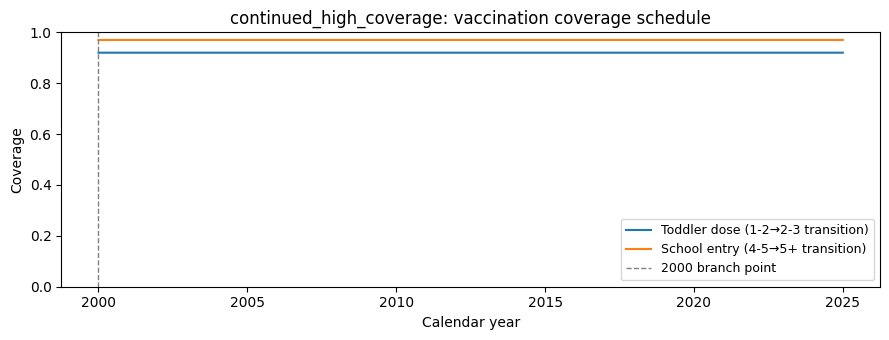

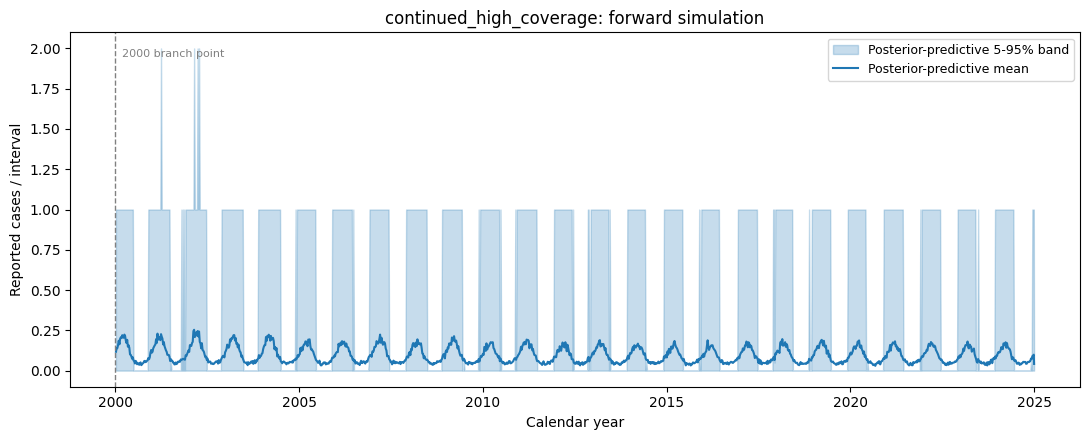

In [ ]:
print('Available experiments:', list(counterfactuals.EXPERIMENTS.keys()))

# Call helper for any desired experiment
result = run_and_plot_experiment(
    experiment_name='continued_high_coverage',
    initial_cloud=cloud_2000,
    theta_hat=theta_hat,
    fixed_parameters=fixed_parameters,
    calendar_years=calendar_years,
    seed=123,
)


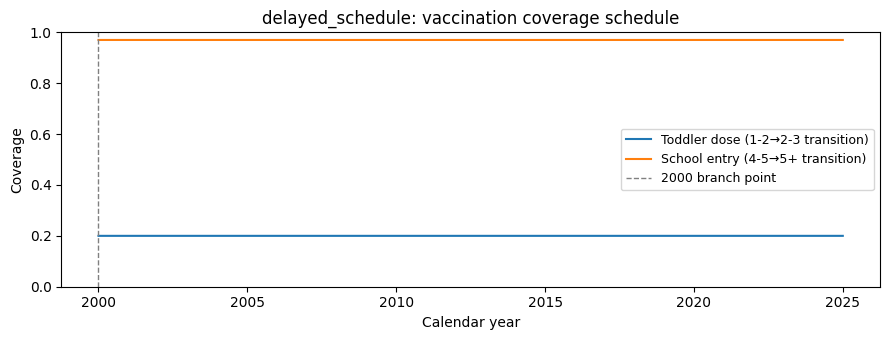

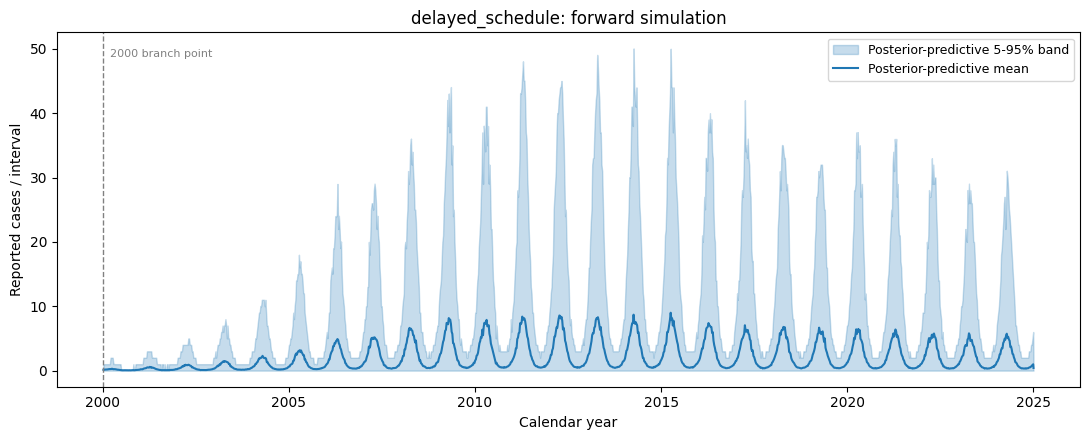

In [ ]:
result = run_and_plot_experiment(
    experiment_name='delayed_schedule',
    initial_cloud=cloud_2000,
    theta_hat=theta_hat,
    fixed_parameters=fixed_parameters,
    calendar_years=calendar_years,
    seed=123,
)

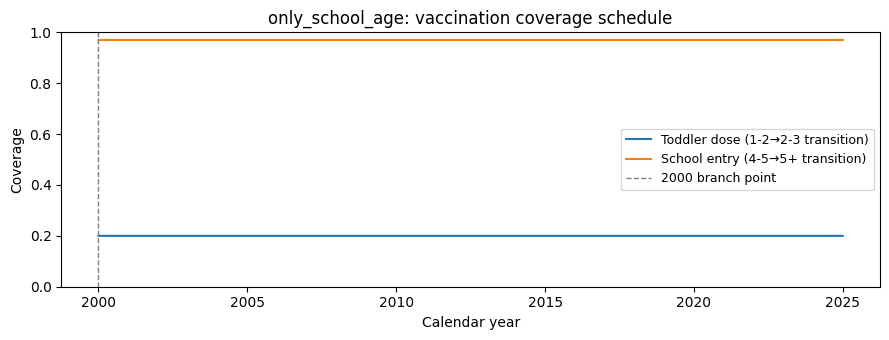

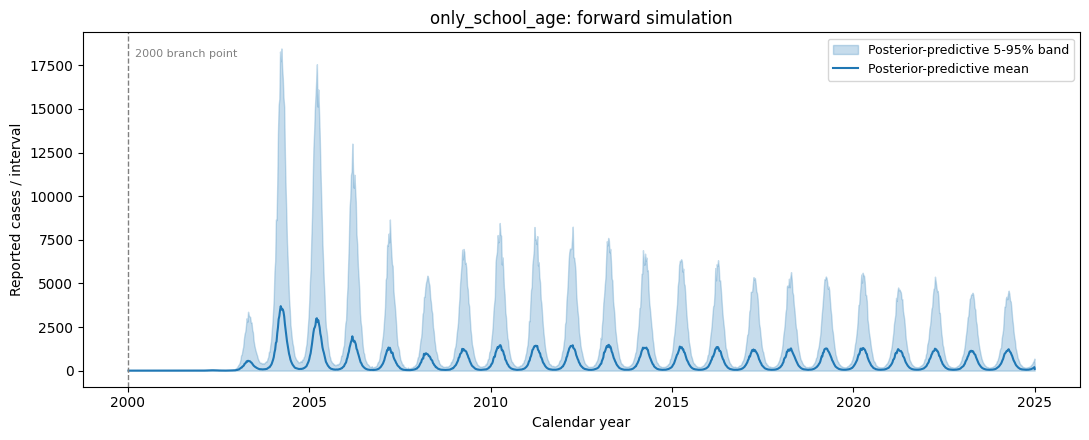

In [ ]:
result = run_and_plot_experiment(
    experiment_name='only_school_age',
    initial_cloud=cloud_2000,
    theta_hat=theta_hat,
    fixed_parameters=fixed_parameters,
    calendar_years=calendar_years,
    seed=123,
)

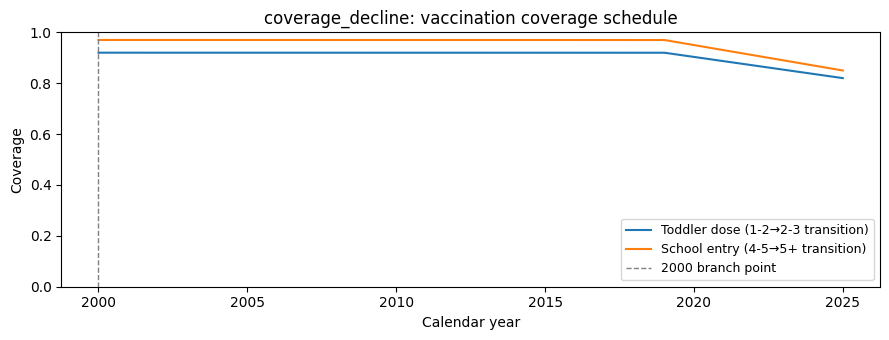

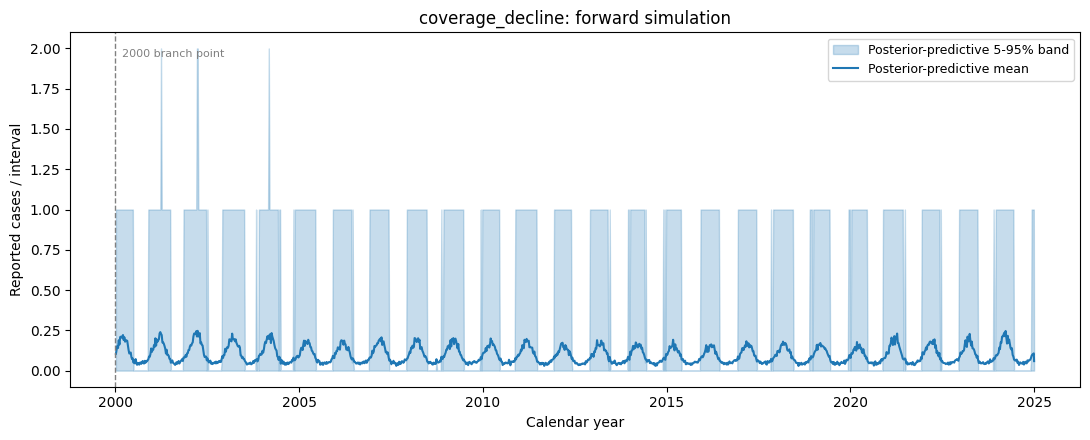

In [ ]:
result = run_and_plot_experiment(
    experiment_name='coverage_decline',
    initial_cloud=cloud_2000,
    theta_hat=theta_hat,
    fixed_parameters=fixed_parameters,
    calendar_years=calendar_years,
    seed=123,
)

In [ ]:
summary_rows = []
cumulative_by_scenario = {}  # scenario -> (P,) array, kept around for the pairwise section below

for scenario_name, result in scenario_results.items():
    cumulative = result.simulated_case_draws.sum(axis=1)  # (P,) -- one cumulative total per particle
    cumulative_by_scenario[scenario_name] = cumulative
    summary_rows.append({
        'scenario': scenario_name,
        'mean_cumulative_cases': cumulative.mean(),
        'median_cumulative_cases': np.median(cumulative),
        'p05': np.percentile(cumulative, 5),
        'p95': np.percentile(cumulative, 95),
        'p_zero_cases': float((cumulative == 0).mean()),  # fraction of particles with NO reported cases -- elimination-like outcomes
    })

summary_df = pd.DataFrame(summary_rows).set_index('scenario')
summary_df

,mean_cumulative_cases,median_cumulative_cases,p05,p95,p_zero_cases
scenario,,,,,
continued_high_coverage,125.2585,118.0,62.00,215.00,0.0
delayed_schedule,2697.7810,1079.0,166.95,11015.70,0.0
only_school_age,572617.7665,586802.0,402723.20,688577.00,0.0
coverage_decline,126.9455,117.0,65.00,219.05,0.0


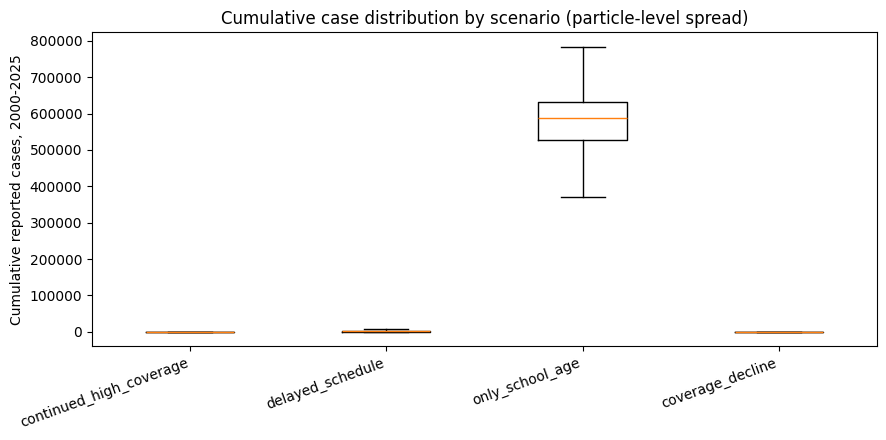

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
scenario_names = list(cumulative_by_scenario.keys())
ax.boxplot(
    [cumulative_by_scenario[s] for s in scenario_names],
    tick_labels=scenario_names,
    showfliers=False,
)
ax.set_ylabel('Cumulative reported cases, 2000-2025')
ax.set_title('Cumulative case distribution by scenario (particle-level spread)')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
fig.tight_layout()
plt.show()

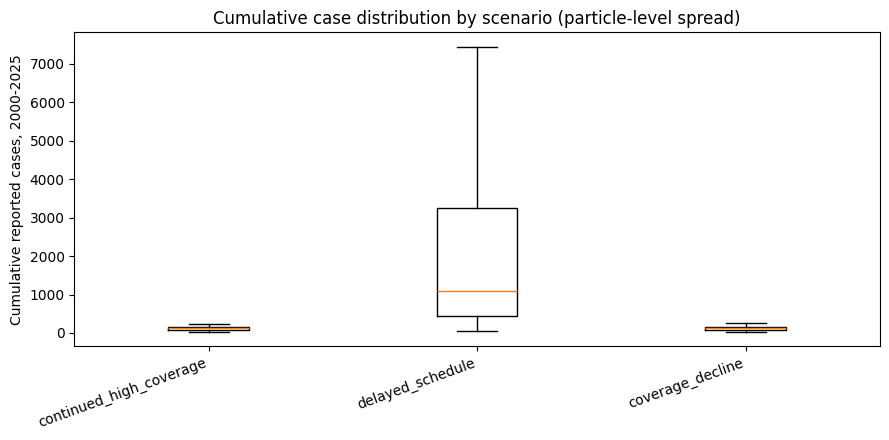

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
reduced_scenario_names = [s for s in list(cumulative_by_scenario.keys()) if s != 'only_school_age' ]
ax.boxplot(
    [cumulative_by_scenario[s] for s in reduced_scenario_names],
    tick_labels=reduced_scenario_names,
    showfliers=False,
)
ax.set_ylabel('Cumulative reported cases, 2000-2025')
ax.set_title('Cumulative case distribution by scenario (particle-level spread)')
plt.setp(ax.get_xticklabels(), rotation=20, ha='right')
fig.tight_layout()
plt.show()

In [ ]:
BASELINE_SCENARIO = 'continued_high_coverage'

pairwise_rows = []
for scenario_name in scenario_names:
    if scenario_name == BASELINE_SCENARIO:
        continue
    diff = cumulative_by_scenario[scenario_name] - cumulative_by_scenario[BASELINE_SCENARIO]
    pairwise_rows.append({
        'scenario': scenario_name,
        'vs_baseline': BASELINE_SCENARIO,
        'mean_excess_cases': diff.mean(),
        'excess_cases_5_95_ci': (float(np.percentile(diff, 5)), float(np.percentile(diff, 95))),
        'P(worse than baseline)': float((diff > 0).mean()),
    })

pairwise_df = pd.DataFrame(pairwise_rows).set_index('scenario')
pairwise_df

,vs_baseline,mean_excess_cases,excess_cases_5_95_ci,P(worse than baseline)
scenario,,,,
delayed_schedule,continued_high_coverage,2572.5225,"(40.95, 10817.949999999999)",0.9700
only_school_age,continued_high_coverage,572492.5080,"(402576.3, 688461.3)",1.0000
coverage_decline,continued_high_coverage,1.6870,"(-54.05, 62.049999999999955)",0.4945
